15:45:09 - cmdstanpy - INFO - Chain [1] start processing
15:45:09 - cmdstanpy - INFO - Chain [1] done processing
15:45:09 - cmdstanpy - INFO - Chain [1] start processing
15:45:09 - cmdstanpy - INFO - Chain [1] done processing
15:45:09 - cmdstanpy - INFO - Chain [1] start processing
15:45:09 - cmdstanpy - INFO - Chain [1] done processing
15:45:09 - cmdstanpy - INFO - Chain [1] start processing
15:45:09 - cmdstanpy - INFO - Chain [1] done processing
15:45:09 - cmdstanpy - INFO - Chain [1] start processing
15:45:09 - cmdstanpy - INFO - Chain [1] done processing
15:45:09 - cmdstanpy - INFO - Chain [1] start processing
15:45:09 - cmdstanpy - INFO - Chain [1] done processing
15:45:09 - cmdstanpy - INFO - Chain [1] start processing
15:45:09 - cmdstanpy - INFO - Chain [1] done processing
15:45:09 - cmdstanpy - INFO - Chain [1] start processing
15:45:09 - cmdstanpy - INFO - Chain [1] done processing
15:45:09 - cmdstanpy - INFO - Chain [1] start processing
15:45:09 - cmdstanpy - INFO - Chain [1]


=== Best Params ===
Prophet: {'changepoint_prior_scale': 0.05, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 10.0}
XGBoost-direct: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_lambda': 0.5}
Hybrid XGB-residual: {'n_estimators': 1000, 'learning_rate': 0.1, 'max_depth': 4, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_lambda': 0.5}

=== Performance on Test (2025-01..07) ===
                          Model   MAE  RMSE    MAPE   sMAPE
                  Prophet (opt) 70.42 84.26 54.35 % 39.83 %
           XGBoost-direct (opt) 59.00 88.90 57.52 % 33.37 %
Hybrid: Prophet + XGB-res (opt) 46.07 50.88 33.13 % 27.11 %

=== Tahmin Tablosu (2025-01..07) ===
   Tarih        Gerçek    Prophet(opt) XGB-direct(opt) Hybrid(opt) 
 2025-01-01      160          150            158           146     
 2025-02-01       96          129            157           131     
 2025-03-01      218          199            234         

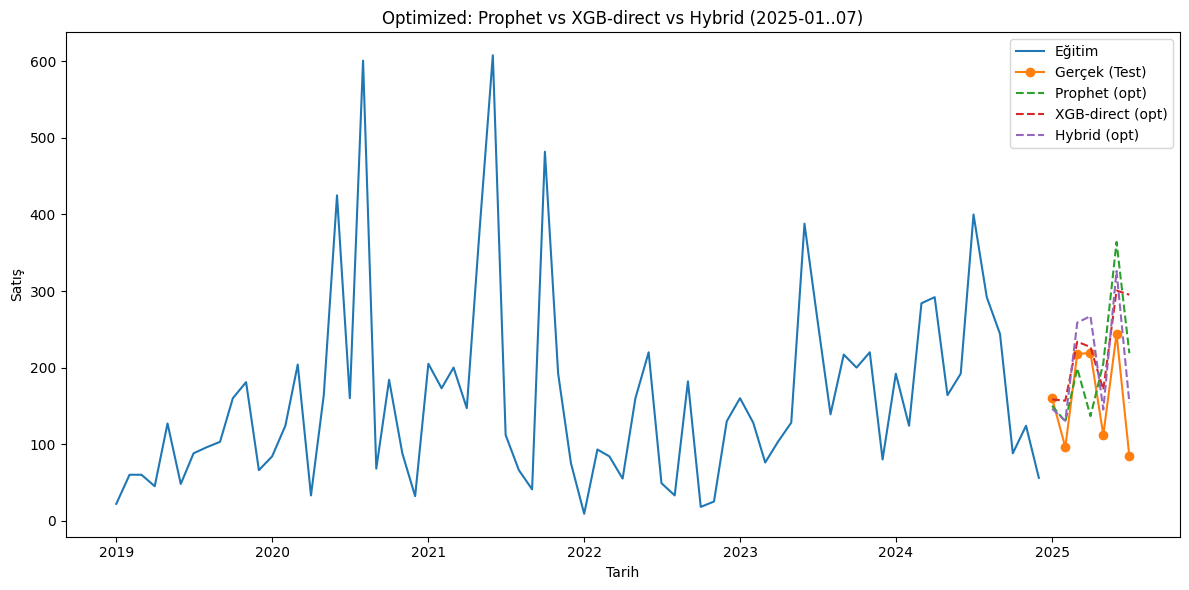

In [2]:
# ===============================================================
#  Hybrid Forecast – Grid Search Optimization
#  Train: 2019-01 .. 2024-12  (MS)
#  Test : 2025-01 .. 2025-07  (MS)
#  Models: Prophet, XGBoost (direct), Hybrid (Prophet + XGB-residual)
#  Metrics: MAE, RMSE, MAPE, sMAPE
# ===============================================================

import warnings
warnings.filterwarnings("ignore")

from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
from xgboost import XGBRegressor

# ----------------------- Helpers -----------------------

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom = np.where(denom == 0, 1.0, denom)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def metrics_dict(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    sm   = smape(y_true, y_pred)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "sMAPE": sm}

def add_features(df):
    """Takvim + lag özellikleri ekler (kampanya yok)."""
    df = df.copy()
    df["month"] = df["ds"].dt.month
    df["year"] = df["ds"].dt.year
    df["is_summer"] = df["ds"].dt.month.isin([6,7,8]).astype(int)
    df["is_winter"] = df["ds"].dt.month.isin([12,1,2]).astype(int)
    # Lag'ler (HAM y'den): 1 ve 12 ay
    df["lag1"]  = df["y"].shift(1)
    df["lag12"] = df["y"].shift(12)
    return df

def print_table(df, title):
    print(f"\n=== {title} ===")
    print(df.to_string(index=False, formatters={
        "MAE":   lambda x: f"{x:,.2f}",
        "RMSE":  lambda x: f"{x:,.2f}",
        "MAPE":  lambda x: f"{x:,.2f} %",
        "sMAPE": lambda x: f"{x:,.2f} %"
    }))

# ----------------------- Data -----------------------

data = {
"2019-01":22,"2019-02":60,"2019-03":60,"2019-04":45,"2019-05":127,
"2019-06":48,"2019-07":88,"2019-08":96,"2019-09":103,"2019-10":160,
"2019-11":181,"2019-12":66,"2020-01":84,"2020-02":124,"2020-03":204,
"2020-04":33,"2020-05":164,"2020-06":425,"2020-07":160,"2020-08":601,
"2020-09":68,"2020-10":184,"2020-11":88,"2020-12":32,"2021-01":205,
"2021-02":173,"2021-03":200,"2021-04":147,"2021-05":380,"2021-06":608,
"2021-07":112,"2021-08":66,"2021-09":41,"2021-10":482,"2021-11":192,
"2021-12":75,"2022-01":9,"2022-02":93,"2022-03":84,"2022-04":55,
"2022-05":160,"2022-06":220,"2022-07":49,"2022-08":33,"2022-09":182,
"2022-10":18,"2022-11":25,"2022-12":130,"2023-01":160,"2023-02":128,
"2023-03":76,"2023-04":104,"2023-05":128,"2023-06":388,"2023-07":264,
"2023-08":139,"2023-09":217,"2023-10":200,"2023-11":220,"2023-12":80,
"2024-01":192,"2024-02":124,"2024-03":284,"2024-04":292,"2024-05":164,
"2024-06":192,"2024-07":400,"2024-08":292,"2024-09":244,"2024-10":88,
"2024-11":124,"2024-12":56,"2025-01":160,"2025-02":96,"2025-03":218,
"2025-04":219,"2025-05":112,"2025-06":244,"2025-07":84
}

# Aylık seri (MS = Month Start)
s = pd.Series(data)
s.index = pd.to_datetime(s.index)  # ayın 1'i
idx_all = pd.date_range("2019-01-01", "2025-07-01", freq="MS")
s = s.reindex(idx_all).astype(float)

df_all = pd.DataFrame({"ds": s.index, "y": s.values})
train_end = pd.Timestamp("2024-12-01")
test_start, test_end = pd.Timestamp("2025-01-01"), pd.Timestamp("2025-07-01")

train_df = df_all[df_all["ds"] <= train_end].copy()
test_df  = df_all[(df_all["ds"] >= test_start) & (df_all["ds"] <= test_end)].copy()
steps = len(test_df)
y_true = test_df["y"].to_numpy()

# ----------------------- Prophet Grid Search -----------------------
prophet_grid = {
    "changepoint_prior_scale": [0.01, 0.05, 0.1, 0.5],
    "seasonality_mode": ["additive", "multiplicative"],
    "seasonality_prior_scale": [1.0, 5.0, 10.0]
}

best_prophet_params = None
best_prophet_pred = None
best_prophet_mae = np.inf
best_prophet_fcst = None  # tüm seri için yhat

for cps, smode, sps in product(prophet_grid["changepoint_prior_scale"],
                               prophet_grid["seasonality_mode"],
                               prophet_grid["seasonality_prior_scale"]):
    try:
        m = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            changepoint_prior_scale=cps,
            seasonality_mode=smode,
            seasonality_prior_scale=sps
        )
        m.fit(train_df[["ds","y"]])
        future = m.make_future_dataframe(periods=steps, freq="MS")
        fcst = m.predict(future)[["ds","yhat"]]

        # Test dönemine denk gelen yhat
        mask = (fcst["ds"] >= test_start) & (fcst["ds"] <= test_end)
        y_pred = fcst.loc[mask, "yhat"].to_numpy()
        if len(y_pred) != steps:
            continue

        mae = mean_absolute_error(y_true, y_pred)
        if mae < best_prophet_mae:
            best_prophet_mae = mae
            best_prophet_params = {"changepoint_prior_scale": cps,
                                   "seasonality_mode": smode,
                                   "seasonality_prior_scale": sps}
            best_prophet_pred = y_pred
            best_prophet_fcst = fcst.copy()
    except Exception:
        continue

# Prophet'in en iyi modeli tüm seriye hizalanmış yhat üretiyor:
df_all = df_all.merge(best_prophet_fcst, on="ds", how="left")

# ----------------------- XGBoost (Direct) Grid Search -----------------------
feat_all = add_features(df_all[["ds","y","yhat"]])  # yhat burada yalnız Prophet için, XGB-direct bunu kullanmaz
mask_train_direct = feat_all["ds"] <= train_end
train_direct = feat_all.loc[mask_train_direct].copy()
test_direct  = feat_all[(feat_all["ds"] >= test_start) & (feat_all["ds"] <= test_end)].copy()

X_cols_basic = ["month","year","is_summer","is_winter"]
X_train_direct = train_direct[X_cols_basic]
y_train_direct = train_direct["y"]
X_test_direct  = test_direct[X_cols_basic]

xgb_grid_direct = {
    "n_estimators": [200, 500, 1000],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0]
}

best_xgbd_params = None
best_xgbd_pred = None
best_xgbd_mae = np.inf

for n, lr, md, ss, cs, rl in product(
    xgb_grid_direct["n_estimators"],
    xgb_grid_direct["learning_rate"],
    xgb_grid_direct["max_depth"],
    xgb_grid_direct["subsample"],
    xgb_grid_direct["colsample_bytree"],
    xgb_grid_direct["reg_lambda"]
):
    try:
        xgb = XGBRegressor(
            n_estimators=n, learning_rate=lr, max_depth=md,
            subsample=ss, colsample_bytree=cs, reg_lambda=rl,
            random_state=42
        )
        xgb.fit(X_train_direct, y_train_direct)
        y_pred = xgb.predict(X_test_direct)
        mae = mean_absolute_error(y_true, y_pred)
        if mae < best_xgbd_mae:
            best_xgbd_mae = mae
            best_xgbd_params = {"n_estimators": n, "learning_rate": lr, "max_depth": md,
                                "subsample": ss, "colsample_bytree": cs, "reg_lambda": rl}
            best_xgbd_pred = y_pred
    except Exception:
        continue

# ----------------------- Hybrid (Prophet + XGB-residual) Grid Search -----------------------
# Residual = y - best_prophet_yhat
feat_all["residual"] = feat_all["y"] - feat_all["yhat"]

# Residual modelinde lag'ler kritik → train kısmında lag1/lag12 NaN olmayan satırlar
mask_train_res = (feat_all["ds"] <= train_end) & feat_all[["lag1","lag12"]].notna().all(axis=1)
train_res = feat_all.loc[mask_train_res].copy()

X_cols_hybrid = ["month","year","is_summer","is_winter","lag1","lag12"]
X_res_train = train_res[X_cols_hybrid]
y_res_train = train_res["residual"]

# Testte de lag'ler hazır (2015-01..07 için var)
mask_test_res = (feat_all["ds"] >= test_start) & (feat_all["ds"] <= test_end)
test_res = feat_all.loc[mask_test_res].copy()
X_res_test = test_res[X_cols_hybrid]

xgb_grid_res = {
    "n_estimators": [200, 500, 1000],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0]
}

best_hyb_params = None
best_hybrid_pred = None
best_hyb_mae = np.inf

for n, lr, md, ss, cs, rl in product(
    xgb_grid_res["n_estimators"],
    xgb_grid_res["learning_rate"],
    xgb_grid_res["max_depth"],
    xgb_grid_res["subsample"],
    xgb_grid_res["colsample_bytree"],
    xgb_grid_res["reg_lambda"]
):
    try:
        xgb_res = XGBRegressor(
            n_estimators=n, learning_rate=lr, max_depth=md,
            subsample=ss, colsample_bytree=cs, reg_lambda=rl,
            random_state=42
        )
        xgb_res.fit(X_res_train, y_res_train)
        resid_pred_test = xgb_res.predict(X_res_test)
        # Hybrid = Prophet_test + Residual_pred_test
        prophet_test_pred = df_all.loc[(df_all["ds"] >= test_start) & (df_all["ds"] <= test_end), "yhat"].to_numpy()
        y_pred = prophet_test_pred + resid_pred_test
        mae = mean_absolute_error(y_true, y_pred)
        if mae < best_hyb_mae:
            best_hyb_mae = mae
            best_hyb_params = {"n_estimators": n, "learning_rate": lr, "max_depth": md,
                               "subsample": ss, "colsample_bytree": cs, "reg_lambda": rl}
            best_hybrid_pred = y_pred
    except Exception:
        continue

# ----------------------- Results & Plots -----------------------
# Prophet en iyi yhat (test) zaten best_prophet_pred
prophet_test_pred = best_prophet_pred
xgb_direct_pred  = best_xgbd_pred
hybrid_pred      = best_hybrid_pred

# Metrics
rows = []
rows.append(metrics_dict(y_true, prophet_test_pred, "Prophet (opt)"))
rows.append(metrics_dict(y_true, xgb_direct_pred,  "XGBoost-direct (opt)"))
rows.append(metrics_dict(y_true, hybrid_pred,      "Hybrid: Prophet + XGB-res (opt)"))
metrics_df = pd.DataFrame(rows)

print("\n=== Best Params ===")
print("Prophet:", best_prophet_params)
print("XGBoost-direct:", best_xgbd_params)
print("Hybrid XGB-residual:", best_hyb_params)

print_table(metrics_df, "Performance on Test (2025-01..07)")

# Tahmin tablosu
compare_df = pd.DataFrame({
    "Tarih": test_df["ds"].values,
    "Gerçek": y_true,
    "Prophet(opt)": prophet_test_pred,
    "XGB-direct(opt)": xgb_direct_pred,
    "Hybrid(opt)": hybrid_pred
})
print("\n=== Tahmin Tablosu (2025-01..07) ===")
print(compare_df.to_string(index=False, justify="center", col_space=12, formatters={
    "Gerçek":           lambda x: f"{x:.0f}",
    "Prophet(opt)":     lambda x: f"{x:.0f}",
    "XGB-direct(opt)":  lambda x: f"{x:.0f}",
    "Hybrid(opt)":      lambda x: f"{x:.0f}"
}))

# Plot
PLOT = True
if PLOT:
    plt.figure(figsize=(12,6))
    plt.plot(df_all[df_all["ds"] <= train_end]["ds"], df_all[df_all["ds"] <= train_end]["y"], label="Eğitim")
    plt.plot(test_df["ds"], y_true, label="Gerçek (Test)", marker="o")
    plt.plot(test_df["ds"], prophet_test_pred, "--", label="Prophet (opt)")
    plt.plot(test_df["ds"], xgb_direct_pred,  "--", label="XGB-direct (opt)")
    plt.plot(test_df["ds"], hybrid_pred,      "--", label="Hybrid (opt)")
    plt.title("Optimized: Prophet vs XGB-direct vs Hybrid (2025-01..07)")
    plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(); plt.tight_layout()
    plt.show()
